In [76]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Открываем файл
file = uproot.open("/Users/pavelsimko/Documents/cub-lab/build/Output_Run_0.root")
hist_3d = file["vdd"]
hist_1d = file["pdd"]

print("Файл успешно загружен. Доступные гистограммы: pdd, vdd")

Файл успешно загружен. Доступные гистограммы: pdd, vdd


In [77]:
# Извлекаем значения
pdd_values = hist_1d.values()
z_edges = hist_1d.axis().edges() / 10.0  # Переводим в см

# Убираем "хвосты" (меньше 5% от макс. дозы), чтобы DUR был честным
mask = pdd_values > (np.max(pdd_values) * 0.05)
clean_pdd = pdd_values[mask]

d_max = np.max(clean_pdd)
d_min = np.min(clean_pdd)
dur = d_max / d_min

print(f"{'Параметр':<20} | {'Значение':<15}")
print("-" * 40)
print(f"{'Max Доза':<20} | {d_max:.2e}")
print(f"{'Min Доза':<20} | {d_min:.2e}")
print(f"{'DUR (Dmax/Dmin)':<20} | {dur:.3f}")

Параметр             | Значение       
----------------------------------------
Max Доза             | 7.53e+04
Min Доза             | 3.48e+04
DUR (Dmax/Dmin)      | 2.167


=== ДИАГНОСТИКА ===
Диапазон центров (см): 0.07 — 31.93
Макс. глубина после обрезки: 31.87 см
Количество бинов после обрезки: 240


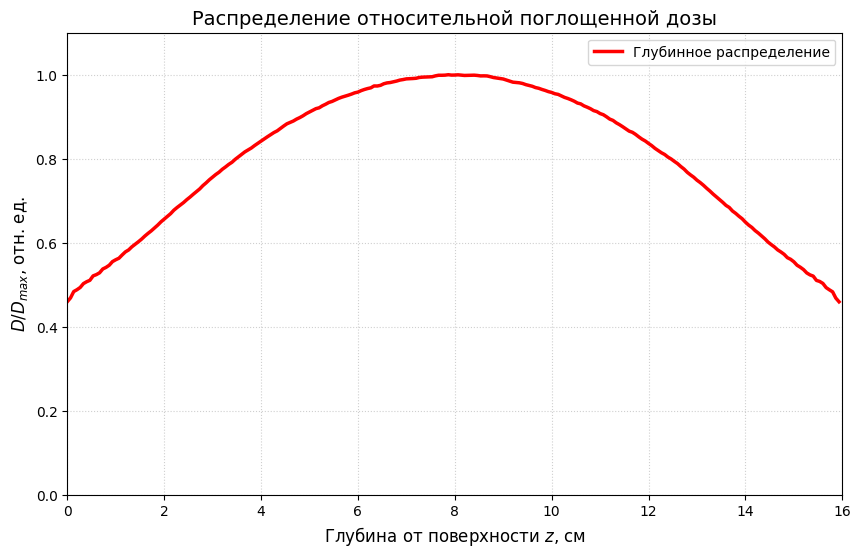

In [74]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# ==================== 1. ЗАГРУЗКА ====================
file = uproot.open("build/Output_Run_0.root")
hist_1d = file["pdd"]

values = hist_1d.values()
edges = hist_1d.axis().edges()
centers = (edges[:-1] + edges[1:]) / 10.0   # мм → см

# ==================== 2. ФИЗИЧЕСКАЯ КОРРЕКЦИЯ + ОБРЕЗКА ====================
z_entrance = np.min(centers)          # входная поверхность (≈ -34 см)
depth = centers - z_entrance

# ←←← ОБРЕЗАЕМ СТРОГО ДО 19 см (ты просил) ←←←
mask = (depth >= 0) & (depth <= 58.0)
x_plot = depth[mask]
y_vals = values[mask]

# ==================== 3. СОРТИРОВКА + НОРМИРОВКА ====================
idx = np.argsort(x_plot)
x_plot = x_plot[idx]
y_plot = y_vals[idx] / np.max(y_vals[idx])   # нормируем только внутри фантома

# ==================== 4. ДИАГНОСТИКА (посмотри в выводе) ====================
print("=== ДИАГНОСТИКА ===")
print(f"Диапазон центров (см): {centers.min():.2f} — {centers.max():.2f}")
print(f"Макс. глубина после обрезки: {x_plot.max():.2f} см")
print(f"Количество бинов после обрезки: {len(x_plot)}")

# ==================== 5. ГРАФИК ====================
plt.figure(figsize=(10, 6))
plt.plot(x_plot/2, y_plot, color='red', lw=2.5, label='Глубинное распределение')

plt.title('Распределение относительной поглощенной дозы', fontsize=14)
plt.xlabel('Глубина от поверхности $z$, см', fontsize=12)
plt.ylabel('$D/D_{max}$, отн. ед.', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, 16)
plt.ylim(0, 1.1)
plt.legend()

plt.show()

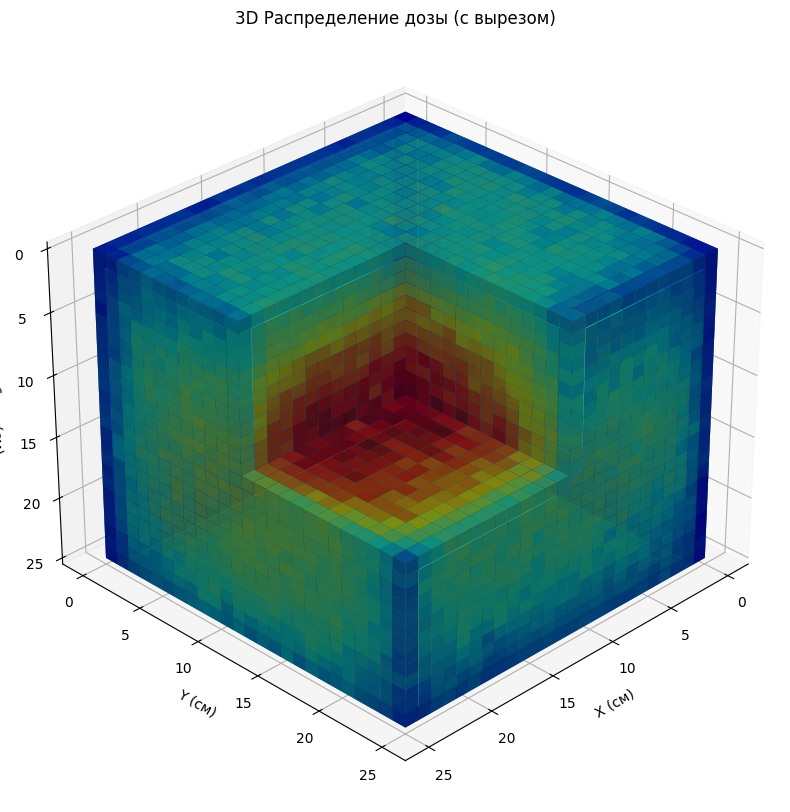

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Загрузка и подготовка
data = hist_3d.values()
# Прореживаем данные в 2 раза, чтобы не висло (было 50x50x50 -> станет 25x25x25)
# Этого за глаза хватит для красивой картинки
step = 2
data = data[::step, ::step, ::step]

# Считаем центры бинов и переводим в см
x_c = (hist_3d.axis(0).edges()[:-1] + hist_3d.axis(0).edges()[1:])[::step] / 10.0
y_c = (hist_3d.axis(1).edges()[:-1] + hist_3d.axis(1).edges()[1:])[::step] / 10.0
z_c = (hist_3d.axis(2).edges()[:-1] + hist_3d.axis(2).edges()[1:])[::step] / 10.0

# Центрируем всё относительно поверхности (0,0,0)
x_c -= np.mean(x_c)
y_c -= np.mean(y_c)
z_surface = np.max(z_c)
z_depth = z_surface - z_c  # Глубина 0...19

# 2. Маска заполнения (Рисуем только там, где есть доза)
threshold = 0.01 * np.max(data)
filled = data > threshold

# ДЕЛАЕМ ВЫРЕЗ (убираем переднюю четверть)
mid_x, mid_y, mid_z = len(x_c)//2, len(y_c)//2, len(z_c)//2
# Убираем угол: X > 0, Y > 0 и верхнюю половину по глубине
filled[mid_x:, mid_y:, :mid_z] = False 

# 3. Цвета
v_max = np.max(data)
norm = data / v_max
colors = plt.cm.jet(norm)
colors[..., 3] = 0.9 # Прозрачность 90%

# 4. Визуализация
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Рисуем воксели. Передаем границы (edges) для сетки
ax.voxels(filled, facecolors=colors, edgecolor='k', linewidth=0.05)

# 5. Оформление и тот самый разворот
ax.set_title("3D Распределение дозы (с вырезом)")
ax.view_init(elev=30, azim=45) # Разворот на 180 (было 45)

# Подписи осей (теперь они относительные)
ax.set_xlabel('X (см)')
ax.set_ylabel('Y (см)')
ax.set_zlabel('Глубина (см)')

# Инвертируем Z, чтобы глубина росла вниз
ax.invert_zaxis()

plt.show()

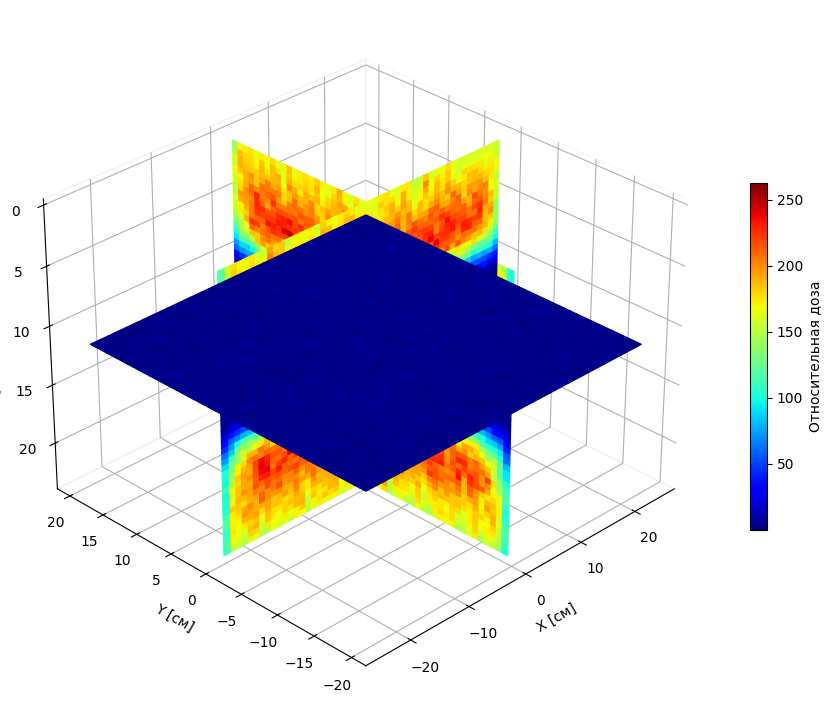

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Подготовка данных
data = hist_3d.values()
x_edges = hist_3d.axis(0).edges() / 10.0 # в см
y_edges = hist_3d.axis(1).edges() / 10.0
z_edges = hist_3d.axis(2).edges() / 10.0

x_c = (x_edges[:-1] + x_edges[1:]) / 2
y_c = (y_edges[:-1] + y_edges[1:]) / 2
z_c = (z_edges[:-1] + z_edges[1:]) / 2

# Инвертируем Z, чтобы 0 был на поверхности (как в PDD)
z_surface = np.max(z_c)
z_depth = z_surface - z_c 

X, Y, Z = np.meshgrid(x_c, y_c, z_depth, indexing='ij')

# 2. Настройка фигуры
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Выбираем индексы для срезов (середина)
mid_x = len(x_c) // 2
mid_y = len(y_c) // 2
mid_z = len(z_c) // 2

# Нормировка цвета
v_max = np.max(data)
norm_colors = data / v_max

# --- РИСУЕМ СРЕЗЫ ---

# Срез по X
ax.plot_surface(X[mid_x, :, :], Y[mid_x, :, :], Z[mid_x, :, :], 
                facecolors=plt.cm.jet(norm_colors[mid_x, :, :]),
                shade=False, antialiased=True, rstride=1, cstride=1)

# Срез по Y
ax.plot_surface(X[:, mid_y, :], Y[:, mid_y, :], Z[:, mid_y, :], 
                facecolors=plt.cm.jet(norm_colors[:, mid_y, :]),
                shade=False, antialiased=True, rstride=1, cstride=1)

# Срез по Z (горизонтальный)
ax.plot_surface(X[:, :, mid_z], Y[:, :, mid_z], Z[:, :, mid_z], 
                facecolors=plt.cm.jet(norm_colors[:, :, mid_z]),
                shade=False, antialiased=True, rstride=1, cstride=1)

# 3. ОФОРМЛЕНИЕ И РАЗВОРОТ
ax.set_xlabel('X [см]')
ax.set_ylabel('Y [см]')
ax.set_zlabel('Глубина [см]')

# Инвертируем ось Z на графике, чтобы 0 был сверху
ax.invert_zaxis()

# РАЗВОРОТ КАМЕРЫ: azim=225 — это поворот на 180 от стандартных 45
ax.view_init(elev=30, azim=225)

# Убираем серые стенки для красоты
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# Цветовая шкала
m = plt.cm.ScalarMappable(cmap=plt.cm.jet)
m.set_array(data)
plt.colorbar(m, ax=ax, shrink=0.5, label='Относительная доза')

plt.show()